# VLM Visual Skills Data Analysis Pipeline
This notebook contains the evaluation, error analysis, and visualization pipeline for video highlight detection and calibration.

In [17]:
import sys
import io
import os
import json
import time
import warnings
import h5py
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Using notebook-friendly tqdm
from scipy.interpolate import interp1d
from scipy.stats import spearmanr, kendalltau
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter1d
from decord import VideoReader, cpu
from collections import Counter
from scipy.spatial import ConvexHull

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from vslice_utils.models import load_vlm, minicpm_extract_title_and_keywords, qwen_extract_title_and_keywords, minicpm_inference, qwen_inference
from vslice_utils.dataloader import build_summe_manifest, build_tvsum_manifest, VideoSegmentDataset
from vslice_utils.measure_calibration import soft_expected_calibration_error
from vslice_utils.helpers import set_seed, temporal_process_features

# Evaluation dependencies
# Jupyter doesn't support __file__, so we use os.path.abspath('')
sys.path.insert(0, os.path.join(os.path.abspath(''), '..', 'csta'))
try:
    from generate_summary import generate_summary
    from evaluation_metrics import get_corr_coeff
    from utils import get_gt
except ImportError:
    generate_summary = get_corr_coeff = get_gt = None

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*not a valid Python identifier.*")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)

# Fix Windows console encoding for non-ASCII characters
if sys.platform == "win32":
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8", errors="replace")
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding="utf-8", errors="replace")

## 1. Evaluation & Metrics
Functions to compute F-score, ECE, correlations, and extract skills.

In [2]:
def compute_video_metrics(yes_scores, no_scores, h5_path, h5_key, video_name, dataset_name, user_scores=None, use_advanced_scoring=False, epsilon=1e-8):
    """
    Calculates F-score, correlations, and ECE using VLM probabilities.
    """
    with h5py.File(h5_path, 'r') as f:
        grp = f[h5_key]
        features = grp['features'][()]
        cps = grp['change_points'][...]
        n_frames = int(grp['n_frames'][...])
        picks = grp['picks'][...]
        gt_scores = grp['gtscore'][...]
        user_summaries = grp['user_summary'][...] if 'user_summary' in grp else [grp['gtsummary'][...]]

    if use_advanced_scoring:
        motion_features = temporal_process_features(features)
        smoothed_motion = gaussian_filter1d(motion_features, sigma=2.0)
        motion_weight = smoothed_motion / (np.mean(smoothed_motion) + epsilon)

        threshold = np.percentile(yes_scores, 95)
        boring_mask = yes_scores < threshold
        
        if not np.any(boring_mask):
            global_feat = np.mean(features, axis=0, keepdims=True)
        else:
            global_feat = np.mean(features[boring_mask], axis=0, keepdims=True)

        features_tensor = torch.tensor(features, dtype=torch.float32)
        global_feat_tensor = torch.tensor(global_feat, dtype=torch.float32)

        relevance_weight = 1.0 - F.cosine_similarity(features_tensor, global_feat_tensor)
        relevance_weight = relevance_weight / (torch.mean(relevance_weight) + epsilon)

        final_scores = yes_scores * motion_weight
        scores = (final_scores - np.min(final_scores)) /(np.max(final_scores) - np.min(final_scores))
    else:
        scores = yes_scores
        
    scores_list = np.squeeze(scores).tolist()
    summary = generate_summary([cps], [scores_list], [n_frames], [picks])[0]
        
    f_scores = []
    for user_summary in user_summaries:
        min_len = min(len(summary), len(user_summary))
        s = summary[:min_len]
        u = user_summary[:min_len]
        
        intersection = np.sum(s * u)
        sum_s = np.sum(s)
        sum_u = np.sum(u)
        
        precision = intersection / sum_s if sum_s > 0 else 0
        recall = intersection / sum_u if sum_u > 0 else 0
        
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
        f_scores.append(f1)
    
    if dataset_name == 'summe':
        rho, tau = get_corr_coeff([summary], [h5_key], 'SumMe', user_summaries)
    else:
        rho, tau = get_corr_coeff([scores_list], [h5_key], 'TVSum', user_scores)

    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    gt_scores_tensor = torch.tensor(gt_scores, dtype=torch.float32)
    global_gt_2d = torch.stack([1.0 - gt_scores_tensor, gt_scores_tensor], dim=1)
    
    p_yes_preds = torch.ones_like(scores_tensor)
    ece = soft_expected_calibration_error(scores_tensor, p_yes_preds, global_gt_2d, num_bins=15)
    
    return {
        "video": video_name,
        "dataset": dataset_name,
        "f_score": np.max(f_scores) if dataset_name == 'summe' else np.mean(f_scores),
        "spearman": rho,
        "kendall": tau,
        "n_frames": n_frames,
        "n_segments": len(cps),
        "ECE": ece
    }

def save_skill(idx, pool, skill_type, error_val, picks, fps, video_id, safe_title, 
               img_dir, all_frames_for_video, cleaned_title, keywords,
               temporal_diff, embedding, logit_yes, logit_no):
    
    sec = picks[idx] / fps
    time_str = f"{int(sec // 60):02d}:{int(sec % 60):02d}"
    img_name = f"{skill_type}_{video_id}_{safe_title}.jpg"
    img_path = os.path.join(img_dir, img_name)
    all_frames_for_video[idx].save(img_path)
    
    pool.append({
            "video_id": video_id,
            "image_path": img_path,
            "title": cleaned_title,
            "keywords": keywords,
            "time": time_str,
            "time_sec": float(sec),
            "frame_idx": int(idx),
            "type": skill_type,
            "error": float(error_val),
            "temporal_diff": float(temporal_diff),
            "embedding": embedding,
            "logit_yes": float(logit_yes),
            "logit_no": float(logit_no)
        })
    return time_str, img_name

def compute_rgb_actionness(frames):
    """
    Computes a normalized motion energy score using direct RGB frame differencing.
    """
    if len(frames) < 2:
        return np.ones(len(frames))
        
    actionness_scores = []
    # Convert first frame to float32 array for diffing
    prev_arr = np.array(frames[0], dtype=np.float32)
    
    for i in range(1, len(frames)):
        curr_arr = np.array(frames[i], dtype=np.float32)
        # Calculate mean absolute difference across all channels (RGB)
        diff = np.abs(curr_arr - prev_arr).mean()
        actionness_scores.append(diff)
        prev_arr = curr_arr
        
    # Pad the first frame so the length matches the number of segments
    actionness_scores.insert(0, actionness_scores[0])
    
    # Normalize to [0, 1]
    max_energy = max(actionness_scores)
    if max_energy > 0:
        actionness_scores = [score / max_energy for score in actionness_scores]
    else:
        actionness_scores = [1.0] * len(actionness_scores)
        
    return np.array(actionness_scores)

## 3. Run Configuration & Main Extraction Pipeline
Iterates over dataset splits, infers highlight scores, computes errors, and stores skill embeddings.

In [3]:
class Args:
    model_type = "minicpm"
    dataset = "summe"
    root_dir = "/home/dexter/LLaVA-VLS"
    output_dir = "/home/dexter/VideoRAG/vslice_features/"
    model_path = None
    split_file = "/home/dexter/VideoRAG/dataset/summe_splits.json"

def resolve_model_path(mtype):
    if mtype == "qwen": return "Qwen/Qwen3.5-9B"
    candidates = ["./MiniCPM-V-2_6-int4", "/home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4"]
    for p in candidates:
        if os.path.exists(p): return p
    return "openbmb/MiniCPM-V-2_6"

# Initialize and Run
args = Args()

if args.model_path is None:
    args.model_path = resolve_model_path(args.model_type)

In [7]:
manifest = []
if args.dataset in ("summe", "both"):
    manifest.extend(build_summe_manifest(args.root_dir))
    dataset_name = "summe"

if args.dataset in ("tvsum", "both"):
    manifest.extend(build_tvsum_manifest(args.root_dir))
    dataset_name = "tvsum"

summe_h5 = os.path.join(args.root_dir, "SumMe", "eccv16_dataset_summe_google_pool5.h5")
tvsum_h5 = os.path.join(args.root_dir, "TVSum", "eccv16_dataset_tvsum_google_pool5.h5")

# Load VLM
print(f"Loading {args.model_type.upper()} model...")
vlm_vars = load_vlm(args.model_path, args.model_type, device)
model, processor, yes_id, no_id = vlm_vars[0], vlm_vars[2], vlm_vars[3], vlm_vars[4]

splits = []
if args.split_file and os.path.exists(args.split_file):
    with open(args.split_file, 'r') as f:
        splits = json.load(f)
    print(f"Loaded {len(splits)} splits from {args.split_file}")

overall_good_skills = []
overall_bad_skills = []
overall_frame_cm = {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0}
overall_errors = []

for split_idx, split in enumerate(splits[:1]):
    print(f"\n==================== SPLIT {split_idx+1}/{len(splits)} ====================")

    split_out_dir = os.path.join(args.output_dir, f"{args.model_type}_skills/{dataset_name}_skills_split_{split_idx}")
    img_dir = os.path.join(split_out_dir, "images")
    os.makedirs(split_out_dir, exist_ok=True)
    os.makedirs(img_dir, exist_ok=True)

    good_skills_json_path = os.path.join(split_out_dir, f"{args.model_type}_good_skills_data.json")
    bad_skills_json_path = os.path.join(split_out_dir, f"{args.model_type}_bad_skills_data.json")
    stats_json_path = os.path.join(split_out_dir, f"{args.model_type}_stats_data.json")

    good_skills_pool, bad_skills_pool = [], []
    train_set = split.get('train_keys', [])

    frame_cm = {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0}
    all_errors_split = []

    print(f"Acquiring visual skills from {len(train_set)} training videos...")
    for video_id in tqdm(train_set, desc="Training"):
        item = next((m for m in manifest if m['h5_key'] == video_id), None)
        if not item: continue

        video_path, title, dataset_name_item = item["video_path"], item["title"], item["dataset"]
        picks, gtscore = item["picks"], item["gtscore"]

        dataset = VideoSegmentDataset(video_path, segment_length=64, width=896, height=672, picks=picks)
        loader = DataLoader(dataset, batch_size=None, shuffle=False, num_workers=4)

        if args.model_type == "minicpm":
            cleaned_title, keywords = minicpm_extract_title_and_keywords(title, model, processor)
        else:
            cleaned_title, keywords = qwen_extract_title_and_keywords(title, model)

        h5_path = summe_h5 if dataset_name_item == "summe" else tvsum_h5
        with h5py.File(h5_path, 'r') as f:
            grp = f[video_id]
            video_features = grp['features'][()]

        all_p_yes, all_frames_for_video, all_hidden_states = [], [], []
        all_logits_yes, all_logits_no  = [], []
        
        pbar = tqdm(loader, desc=f"VLM Inference: {title}, {cleaned_title}:, {keywords}", leave=False)
        for frames, start, end in pbar:
            if args.model_type == "minicpm":
                p_yes, p_no, logit_yes, logit_no, hidden_states = minicpm_inference(frames, cleaned_title, keywords, model, processor, yes_id, no_id)
            else:
                p_yes, p_no, logit_yes, logit_no, hidden_states = qwen_inference(frames, cleaned_title, keywords, model, yes_id, no_id)

            all_p_yes.append(p_yes.detach().cpu().float().numpy())
            all_frames_for_video.extend(frames)
            all_hidden_states.append(hidden_states.detach().cpu().float().numpy())
            all_logits_yes.append(logit_yes.detach().cpu().float().numpy())
            all_logits_no.append(logit_no.detach().cpu().float().numpy())

        raw_p_yes = np.concatenate(all_p_yes)
        raw_logit_yes = np.concatenate(all_logits_yes)
        raw_logit_no = np.concatenate(all_logits_no)
        raw_hidden_states = np.concatenate(all_hidden_states, axis=0)

        temp_diffs = temporal_process_features(video_features)
        error = raw_p_yes - gtscore

        # ──────────────────────── NEW FEATURE EXTRACTION ────────────────────────
        # 1. Temporal Smoothness (Local Variance in a 5-segment window)
        p_yes_series = pd.Series(raw_p_yes)
        local_variance = p_yes_series.rolling(window=5, center=True).var().fillna(0).values

        # 2. Neighbouring Prediction Stats (Isolation Score)
        # How much higher is this segment than the average of its neighbors?
        local_mean = p_yes_series.rolling(window=5, center=True).mean().bfill().ffill().values
        isolation_scores = raw_p_yes - local_mean
        # ────────────────────────────────────────────────────────────────────────

        pred_binary = (raw_p_yes > 0.5).astype(int)
        gt_binary = (gtscore > 0.5).astype(int)

        frame_cm['tp'] += int(np.sum((pred_binary == 1) & (gt_binary == 1)))
        frame_cm['fp'] += int(np.sum((pred_binary == 1) & (gt_binary == 0)))
        frame_cm['fn'] += int(np.sum((pred_binary == 0) & (gt_binary == 1)))
        frame_cm['tn'] += int(np.sum((pred_binary == 0) & (gt_binary == 0)))
        all_errors_split.extend(error.tolist())

        tp_scores = gtscore * raw_p_yes
        tp_idx = np.argmax(tp_scores)

        fn_scores = gtscore * (1.0 - raw_p_yes)
        fn_idx = np.argmax(fn_scores)

        fp_scores = (1.0 - gtscore) * raw_p_yes
        fp_idx = np.argmax(fp_scores)

        tn_scores = (1.0 - gtscore) * (1.0 - raw_p_yes)
        tn_idx = np.argmax(tn_scores)

        safe_title = title.replace(" ", "_").replace("/", "_")

        tp_time, tp_img = save_skill(
        tp_idx, good_skills_pool, "tp", error[tp_idx], picks, dataset.fps, video_id, safe_title, 
        img_dir, all_frames_for_video, cleaned_title, keywords, 
        temp_diffs[tp_idx], raw_hidden_states[tp_idx], 
        raw_logit_yes[tp_idx], raw_logit_no[tp_idx]
        )
        
        fn_time, fn_img = save_skill(
            fn_idx, good_skills_pool, "fn", error[fn_idx], picks, dataset.fps, video_id, safe_title, 
            img_dir, all_frames_for_video, cleaned_title, keywords, 
            temp_diffs[fn_idx], raw_hidden_states[fn_idx], 
            raw_logit_yes[fn_idx], raw_logit_no[fn_idx]
        )
        
        fp_time, fp_img = save_skill(
            fp_idx, bad_skills_pool, "fp", error[fp_idx], picks, dataset.fps, video_id, safe_title, 
            img_dir, all_frames_for_video, cleaned_title, keywords, 
            temp_diffs[fp_idx], raw_hidden_states[fp_idx], 
            raw_logit_yes[fp_idx], raw_logit_no[fp_idx]
        )
        
        tn_time, tn_img = save_skill(
            tn_idx, bad_skills_pool, "tn", error[tn_idx], picks, dataset.fps, video_id, safe_title, 
            img_dir, all_frames_for_video, cleaned_title, keywords, 
            temp_diffs[tn_idx], raw_hidden_states[tn_idx], 
            raw_logit_yes[tn_idx], raw_logit_no[tn_idx]
        )
    overall_good_skills.extend(good_skills_pool)
    overall_bad_skills.extend(bad_skills_pool)
    for key in overall_frame_cm:
        overall_frame_cm[key] += frame_cm[key]
    overall_errors.extend(all_errors_split)
    
print(f"\n==================== OVERALL EXTRACTION COMPLETE ({dataset_name.upper()}) ====================")

[DATA] SumMe: 25 videos discovered
[DATA] TVSum: 50 / 50 videos resolved
Loading MINICPM model...
[cuda] Loading minicpm from /home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4...


Loading weights:   0%|          | 0/789 [00:00<?, ?it/s]

[cuda] [OK] MiniCPM Loaded (Yes=9454, No=2753)
Loaded 5 splits from /home/dexter/VideoRAG/dataset/summe_splits.json

==================== SPLIT 1/5 ====================
Acquiring visual skills from 20 training videos...


Training:   0%|          | 0/20 [00:00<?, ?it/s]

VLM Inference: Air Force One, Air Force One:, airplane, military, president:   0%|          | 0/5 [00:00<?, ?i…

...

VLM Inference: Bus in Rock Tunnel, Bus in Rock Tunnel:, tunnel, bus, rock:   0%|          | 0/6 [00:00<?, ?it/…

VLM Inference: Car railcrossing, Car railcross:, rail, car, crossing:   0%|          | 0/6 [00:00<?, ?it/s]

VLM Inference: Cockpit Landing, Cockpit Landing:, landing, aircraft, aviation:   0%|          | 0/10 [00:00<?,…

VLM Inference: Cooking, Cooking:, cooking, kitchen, food:   0%|          | 0/2 [00:00<?, ?it/s]


==================== OVERALL EXTRACTION COMPLETE (TVSUM) ====================


In [ ]:
# 2. Testing Phase: Use Skills for Reprompting
print(f"\nEvaluating test set with acquired skills...")
test_set = split['test_keys']
split_results = []

if "tvsum" in args.split_file.lower() and get_gt is not None:
    tvsum_user_scores = get_gt('TVSum')
else:
    tvsum_user_scores = None

for video_id in test_set:
    item = next((m for m in manifest if m['h5_key'] == video_id), None)
    if not item: continue
    
    video_path, title, dataset_name = item["video_path"], item["title"], item["dataset"]
    picks, h5_path = item["picks"], summe_h5 if dataset_name == "summe" else tvsum_h5
    
    print(f"\n[EVAL] {dataset_name}/{item['video_name']} | \"{title}\"")
    
    # Run Inference w/ Skills reprompting
    dataset = VideoSegmentDataset(video_path, segment_length=32, width=896, height=672, picks=picks)
    loader = DataLoader(dataset, batch_size=None, shuffle=False, num_workers=4)

    # Extract Title Keywords
    if args.model_type == "minicpm":
        cleaned_title, keywords = minicpm_extract_title_and_keywords(title, model, processor)
    else:
        cleaned_title, keywords = qwen_extract_title_and_keywords(title, model)

    all_p_yes, all_p_no, all_hidden_states = [], [], []
    for frames, _, _ in loader:
        if args.model_type == "minicpm":
            p_yes, p_no, _, _, hidden_states_test = minicpm_inference(frames, cleaned_title, keywords, model, processor, yes_id, no_id)
        else:
            p_yes, p_no, _, _, _ = qwen_inference(frames, cleaned_title, keywords, model, yes_id, no_id)

        all_p_yes.append(p_yes.detach().cpu().float().numpy())
        all_p_no.append(p_no.detach().cpu().float().numpy())
        all_hidden_states.append(hidden_states_test.detach().cpu().float().numpy())

    raw_p_yes, raw_p_no = np.concatenate(all_p_yes), np.concatenate(all_p_no)
    hidden_states_test = np.concatenate(all_hidden_states, axis=0)

    res = compute_video_metrics(
        yes_scores=raw_p_yes, 
        no_scores=raw_p_no, 
        h5_path=h5_path, 
        h5_key=video_id, 
        video_name=item['video_name'],
        dataset_name=dataset_name, 
        user_scores=tvsum_user_scores,
        use_advanced_scoring=True
    )
    
    print(f"  --> F-Score: {res['f_score']:.4f} | Kendall: {res['kendall']:.4f} | Spearman: {res['spearman']:.4f}")


Evaluating test set with acquired skills...

[EVAL] summe/Playing_on_water_slide | "Playing on water slide"
  --> F-Score: 0.5978 | Kendall: 0.0155 | Spearman: 0.0174

[EVAL] summe/Uncut_Evening_Flight | "Uncut Evening Flight"
  --> F-Score: 0.1912 | Kendall: 0.0414 | Spearman: 0.0458

[EVAL] summe/playing_ball | "playing ball"


In [11]:
good_df = pd.DataFrame(good_skills_pool)
bad_df = pd.DataFrame(bad_skills_pool)
df = pd.concat([good_df, bad_df])
df.head()
df.to_csv(f'{dataset_name}_skills.csv', index=False)

In [14]:
print("Median Temporal Motion by Classification:")
print(df.groupby('type')['temporal_diff'].median().sort_values(ascending=False))

Median Temporal Motion by Classification:
type
fn    1.624038
fp    1.412406
tp    1.192643
tn    0.881850
Name: temporal_diff, dtype: float64


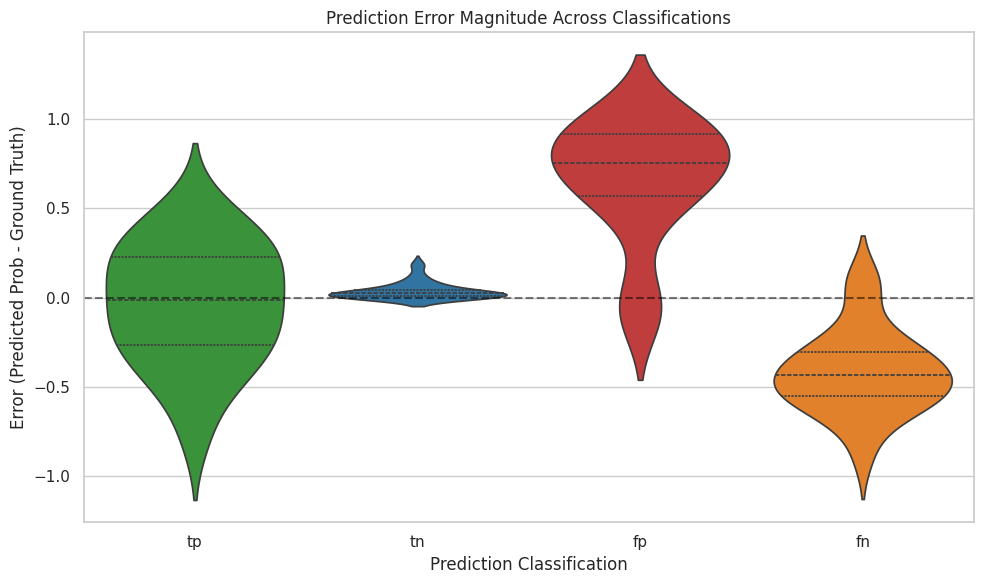

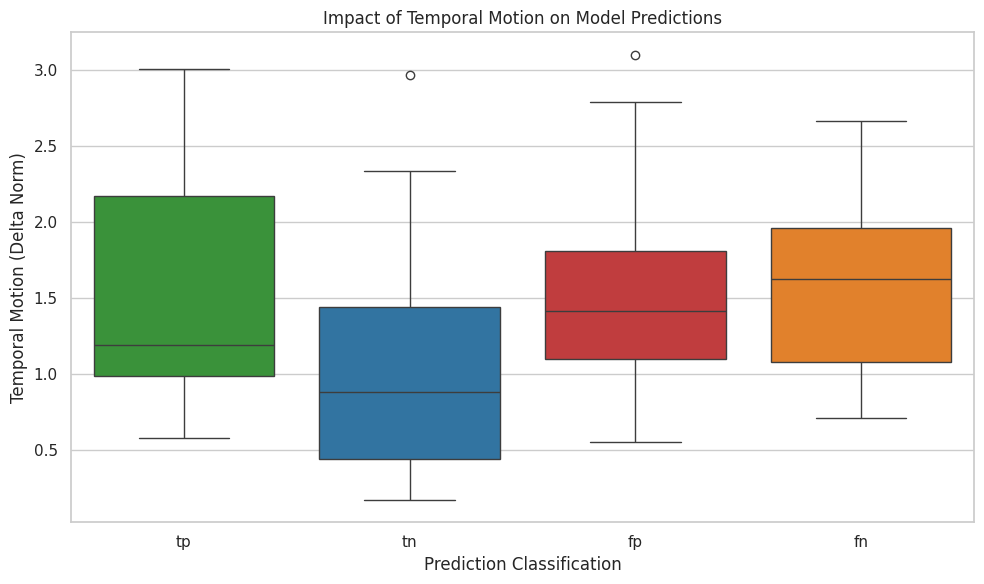

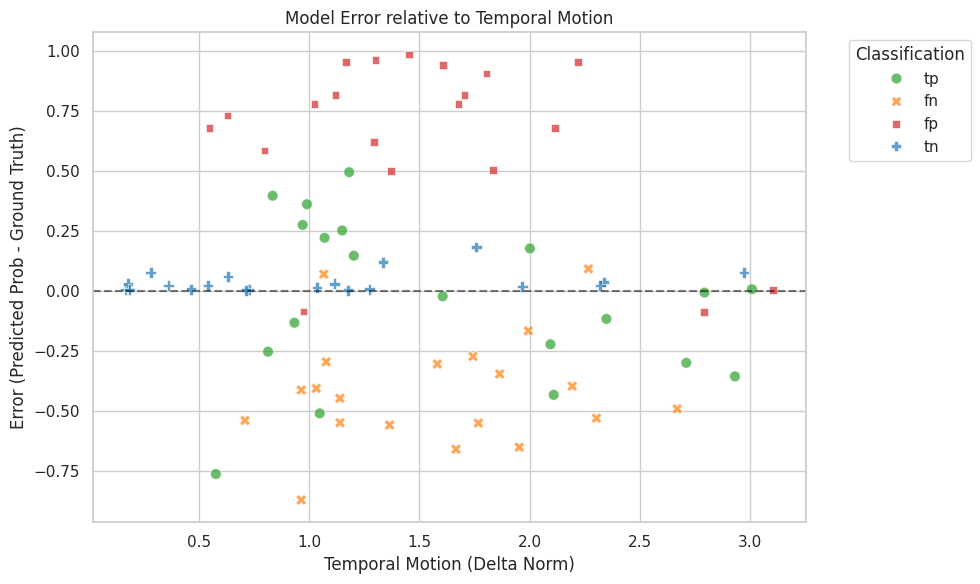

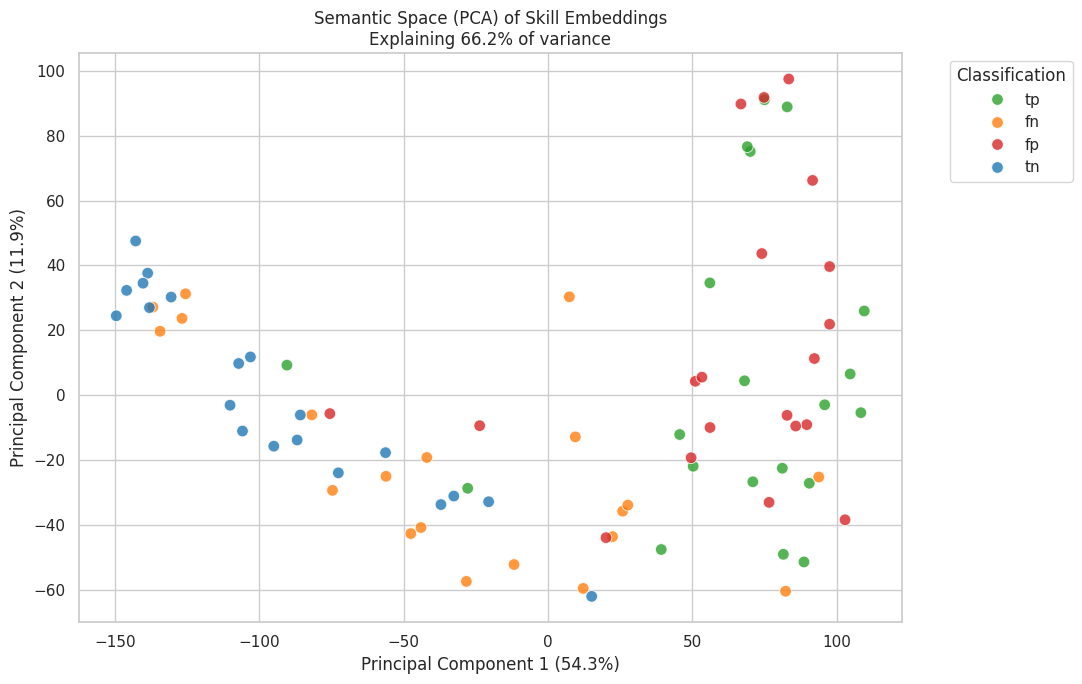

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.decomposition import PCA

# 1. Load and Clean the Data
# Replace 'combined_skills_data.csv' with your actual filename
good_df = pd.DataFrame(good_skills_pool)
bad_df = pd.DataFrame(bad_skills_pool)

df = pd.concat([good_df, bad_df])

# The 'embedding' column is likely saved as a string representation of a list. 
# We need to safely evaluate it back into a numpy array for PCA.
df['embedding'] = df['embedding'].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x)

# Set the visual style for seaborn
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# FIGURE 2: Error Distribution by Type
# ==========================================
# Since error = (Prediction - GT), FPs will be highly positive and FNs highly negative.
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='type', y='error', order=['tp', 'tn', 'fp', 'fn'], 
               palette=['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'], inner="quartile")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Prediction Error Magnitude Across Classifications')
plt.xlabel('Prediction Classification')
plt.ylabel('Error (Predicted Prob - Ground Truth)')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: Temporal Motion vs. Errors
# ==========================================
# Are False Positives caused by high temporal motion confusing the VLM?
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='type', y='temporal_diff', order=['tp', 'tn', 'fp', 'fn'], 
            palette=['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'])
plt.title('Impact of Temporal Motion on Model Predictions')
plt.xlabel('Prediction Classification')
plt.ylabel('Temporal Motion (Delta Norm)')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 4: Bivariate Relationship (Motion vs Error)
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temporal_diff', y='error', hue='type', style='type',
                palette={'tp': '#2ca02c', 'tn': '#1f77b4', 'fp': '#d62728', 'fn': '#ff7f0e'},
                alpha=0.7, s=60)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Model Error relative to Temporal Motion')
plt.xlabel('Temporal Motion (Delta Norm)')
plt.ylabel('Error (Predicted Prob - Ground Truth)')
plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 5: PCA of Embeddings in Seaborn
# ==========================================
if not df['embedding'].isna().all():
    # Extract the embeddings into a 2D matrix
    X = np.stack(df['embedding'].values)
    
    # Compute 2D PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X)
    
    # Add back to DataFrame for Seaborn plotting
    df['pca_1'] = pca_result[:, 0]
    df['pca_2'] = pca_result[:, 1]
    
    plt.figure(figsize=(11, 7))
    sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='type', 
                    palette={'tp': '#2ca02c', 'tn': '#1f77b4', 'fp': '#d62728', 'fn': '#ff7f0e'},
                    alpha=0.8, edgecolor='w', s=70)
    
    plt.title(f'Semantic Space (PCA) of Skill Embeddings\nExplaining {sum(pca.explained_variance_ratio_)*100:.1f}% of variance')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
df[df['type'] == "tp"]


In [ ]:
# Plotting a histogram to see distribution overlap
plt.hist(df[df['type'] == "tp"]["contrast"], bins=20, alpha=0.6, label="TP")
plt.hist(df[df['type'] == "fp"]["contrast"], bins=20, alpha=0.6, label="FP")

plt.xlabel("Logit Contrast (Yes - No)")
plt.ylabel("Frequency")
plt.legend()
plt.title("TP vs FP Contrast Distribution")
plt.show()

In [ ]:
df['contrast'] = df['logit_yes'] - df['logit_no']

# Print the stats for True Positives
print("TP Contrast Mean/Std:", 
      df[df['type'] == "tp"]["contrast"].mean(), 
      df[df['type'] == "tp"]["contrast"].std())

# Print the stats for False Positives
print("FP Contrast Mean/Std:", 
      df[df['type'] == "fp"]["contrast"].mean(), 
      df[df['type'] == "fp"]["contrast"].std())

In [ ]:
import numpy as np

# 1. Calculate the Global Centroid per video (the "Average" look of that video)
video_centroids = {}
for vid in df['video_id'].unique():
    vid_frames = df[df['video_id'] == vid]
    if len(vid_frames) > 0:
        # Get all embeddings for this video
        embeddings_stack = np.stack(vid_frames['embedding'].values)
        video_centroids[vid] = np.mean(embeddings_stack, axis=0)

# 2. Compute the Semantic Deviation (Cosine Distance from the video mean)
def get_deviation(row):
    vid = row['video_id']
    if vid in video_centroids:
        mean_emb = video_centroids[vid]
        curr_emb = row['embedding']
        # Cosine Similarity calculation
        norm_prod = (np.linalg.norm(curr_emb) * np.linalg.norm(mean_emb)) + 1e-8
        cos_sim = np.dot(curr_emb, mean_emb) / norm_prod
        return 1.0 - cos_sim # Cosine Distance
    return np.nan

df['dist_to_mean'] = df.apply(get_deviation, axis=1)

# 3. Compare TPs vs FPs using the new column
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['type'].isin(['tp', 'fp'])], x='dist_to_mean', hue='type', 
            fill=True, palette={'tp': '#2ca02c', 'fp': '#d62728'}, common_norm=False)

plt.title('Semantic Deviation: Are TPs more "Unique" than FPs?')
plt.xlabel('Cosine Distance from Video Mean')
plt.ylabel('Density')
plt.show()

dist_summary = df[df['type'].isin(['tp', 'fp'])].groupby('type')['dist_to_mean'].mean()
print("Average Semantic Deviation (Higher = More unique/less like background):")
print(dist_summary)

## 4. Analysis

In [ ]:
plt.figure(figsize=(9, 6))
weights = np.ones_like(all_errors_split) / len(all_errors_split)
plt.hist(all_errors_split, bins=15, weights=weights, color='turquoise', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Calibration (Ideal)')
    
plt.title(f'Distribution of Prediction Errors')
plt.xlabel('Model Error')
plt.ylabel('Sample Frequency')

xmin, xmax = plt.xlim()
plt.axvspan(xmin, 0, color='blue', alpha=0.1, label='Under-predict', zorder=1)
plt.axvspan(0, xmax, color='red', alpha=0.05, label='Over-predict', zorder=1)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()